In [2]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import cv2
from PIL import Image
import numpy as np
import tensorflow as tf
import keras
from keras import layers

In [6]:
images = []
labels = []

path = 'D://Thumbs'
target_size = (100, 100)

for folder in ['Bad_balanced', 'Good_valid']:
    filepath = os.path.join(path, folder)
    label = 0 if folder == 'Bad_balanced' else 1  # 0 for Bad, 1 for Good

    for file in os.listdir(filepath):
        if not file.endswith('.png'):
            continue

        img_path = os.path.join(filepath, file)

        try:
            img = Image.open(img_path).convert('L')
            img = img.resize(target_size)
            img = np.array(img)
            img = img.reshape((100, 100, 1))  # shape for CNN
            images.append(img)
            labels.append(label)
        except Exception as e:
            print(f"Skipping {file}: {e}")
            continue

# Convert to numpy arrays
x = np.array(images, dtype='float32') / 255.0  # normalize here or use Rescaling layer
y = np.array(labels)


Skipping 11__M_Left_middle_finger.png: Truncated IHDR chunk
Skipping 11__M_Left_ring_finger.png: cannot identify image file 'D:\\Thumbs\\Good_valid\\11__M_Left_ring_finger.png'
Skipping 12__M_Left_little_finger.png: broken data stream when reading image file
Skipping 18__M_Right_thumb_finger.png: Truncated File Read
Skipping 19__M_Right_ring_finger.png: unrecognized data stream contents when reading image file
Skipping 21__M_Left_index_finger.png: unrecognized data stream contents when reading image file
Skipping 25__F_Right_little_finger.png: broken data stream when reading image file
Skipping 25__F_Right_thumb_finger.png: cannot identify image file 'D:\\Thumbs\\Good_valid\\25__F_Right_thumb_finger.png'
Skipping 26__M_Left_index_finger.png: unrecognized data stream contents when reading image file
Skipping 26__M_Left_middle_finger.png: cannot identify image file 'D:\\Thumbs\\Good_valid\\26__M_Left_middle_finger.png'
Skipping 26__M_Right_little_finger.png: broken data stream when readi

In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test,y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [6]:
# model without augmentation

model  = tf.keras.Sequential([
    layers.Input(shape=(100,100,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
    
])

In [7]:
model.compile(loss = 'binary_crossentropy', optimizer=keras.optimizers.RMSprop(learning_rate=0.01), metrics=['accuracy'])

In [11]:
history = model.fit(x_train, y_train, epochs= 15, validation_data=(x_test, y_test), batch_size=32)

Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 292ms/step - accuracy: 0.5083 - loss: 22.9671 - val_accuracy: 0.7184 - val_loss: 0.4722
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 278ms/step - accuracy: 0.8140 - loss: 0.4321 - val_accuracy: 0.5000 - val_loss: 2.5357
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 285ms/step - accuracy: 0.8192 - loss: 0.8423 - val_accuracy: 0.9000 - val_loss: 0.2061
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 15s 307ms/step - accuracy: 0.9104 - loss: 0.2436 - val_accuracy: 0.9316 - val_loss: 0.1733
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 299ms/step - accuracy: 0.8977 - loss: 0.2703 - val_accuracy: 0.7053 - val_loss: 0.6360
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 282ms/step - accuracy: 0.8924 - loss: 0.2933 - val_accuracy: 0.9263 - val_loss: 0.1651
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 15s 320ms/step - accuracy: 0.9327 - loss: 0.1705 - val_accuracy: 0.9526 - val_loss: 0.1135
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 326ms/step - accuracy: 0.9434 - loss: 0.1491 - val_acc

In [8]:
#model with augmentation

model_with_augmentation  = tf.keras.Sequential([
    layers.Input(shape=(100,100,1)),
    # layers.RandomFlip('horizontal'), shouldnt be used as it will flipp the finger prints
    layers.RandomRotation(0.02, fill_mode= 'nearest'),
    layers.RandomTranslation(0.02, 0.02, fill_mode= 'nearest'),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
    
])

In [9]:
model_with_augmentation.compile(loss = 'binary_crossentropy', optimizer=keras.optimizers.RMSprop(learning_rate=0.01), metrics=['accuracy'])

In [10]:
history = model_with_augmentation.fit(x_train, y_train, epochs= 35, validation_data=(x_test, y_test), batch_size=32)

Epoch 1/35
 6/48 ━━━━━━━━━━━━━━━━━━━━ 18s 430ms/step - accuracy: 0.4674 - loss: 57.4916

KeyboardInterrupt: 

In [8]:
#model with augmentation using datagenerator

model_with_datagenerator  = tf.keras.Sequential([
    layers.Input(shape=(100,100,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
    
])

In [9]:
model_with_datagenerator.compile(loss = 'binary_crossentropy', optimizer=keras.optimizers.RMSprop(learning_rate=0.01), metrics=['accuracy'])

In [10]:
from keras.callbacks import Callback

class myCallBack(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs['accuracy']>=0.95:
            print("desired accuracy recieved so cancelling training")
            self.model.stop_training = True


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmentation (NO flipping)
datagen = ImageDataGenerator(
    rotation_range=2,
    width_shift_range=0.02,
    height_shift_range=0.02,
    fill_mode='nearest'
)

# Fit the generator on training data
datagen.fit(x_train)

# Use it during training
model_history =model_with_datagenerator.fit(datagen.flow(x_train, y_train, batch_size=32),
          validation_data=(x_test, y_test),
          epochs=30, callbacks=[myCallBack()])


c:\Users\PMLS\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 345ms/step - accuracy: 0.4867 - loss: 20.7442 - val_accuracy: 0.4933 - val_loss: 0.6936
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 290ms/step - accuracy: 0.5225 - loss: 0.6928 - val_accuracy: 0.5067 - val_loss: 0.6933
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 298ms/step - accuracy: 0.4941 - loss: 0.6946 - val_accuracy: 0.5067 - val_loss: 0.6931
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 291ms/step - accuracy: 0.4732 - loss: 0.6937 - val_accuracy: 0.4933 - val_loss: 0.6933
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 295ms/step - accuracy: 0.5155 - loss: 3.1861 - val_accuracy: 0.6187 - val_loss: 0.6797
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 298ms/step - accuracy: 0.5849 - loss: 0.6827 - val_accuracy: 0.4933 - val_loss: 0.6864
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 290ms/step - accuracy: 0.5976 - loss: 0.6983 - val_accuracy: 0.6800 - val_loss: 0.6418
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 292ms/step - accuracy: 0.7061 - loss: 0.6906 - val_acc

In [23]:
model_with_datagenerator.save('ccn_model_datagenerator.keras')

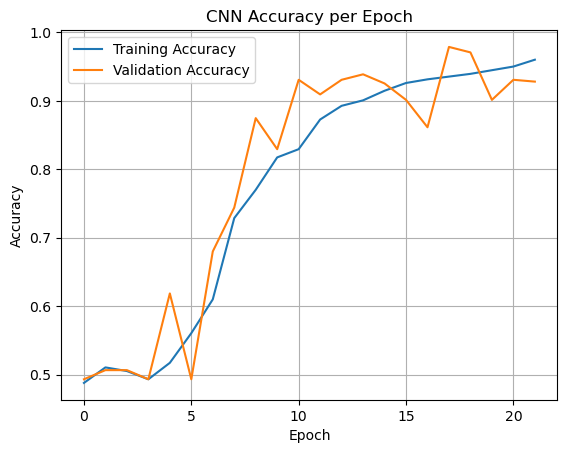

In [13]:
import matplotlib.pyplot as plt


plt.plot(model_history.history['accuracy'], label='Training Accuracy')
plt.plot(model_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


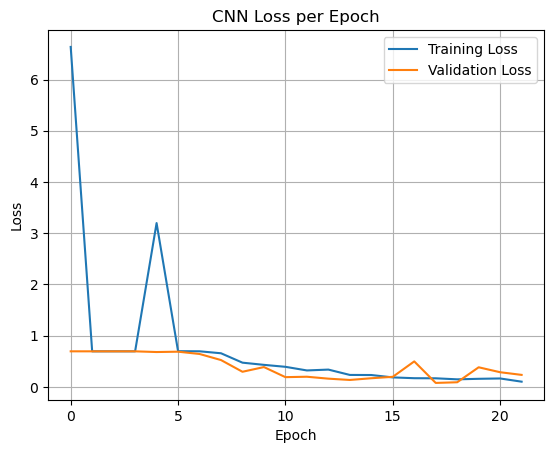

In [14]:
plt.plot(model_history.history['loss'], label='Training Loss')
plt.plot(model_history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
